In [ ]:
import os, sys, time, math, subprocess, importlib

def _sh(cmd):
    print("$", cmd, flush=True)
    subprocess.run(cmd, shell=True, check=False)

def ensure_pytorch3d():
    try:
        import pytorch3d
        print("pytorch3d already present:", pytorch3d.__version__)
        return
    except ModuleNotFoundError:
        pass

    import torch
    _sh(f"{sys.executable} -m pip install -q fvcore iopath ninja")

    if torch.cuda.is_available() and torch.version.cuda is not None:
        pyt = torch.__version__.split("+")[0].replace(".", "")
        tag = f"py3{sys.version_info.minor}_cu{torch.version.cuda.replace('.', '')}_pyt{pyt}"
        url = f"https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/{tag}/download.html"
        _sh(f"{sys.executable} -m pip install -q --no-index --no-cache-dir pytorch3d -f {url}")

    importlib.invalidate_caches()
    try:
        import pytorch3d
        print("Installed prebuilt wheel:", pytorch3d.__version__)
        return
    except ModuleNotFoundError:
        pass

    print("\nNo matching wheel -> building from source (~10-20 min, one time).\n")
    if torch.cuda.is_available():
        cc = torch.cuda.get_device_capability(0)
        os.environ["TORCH_CUDA_ARCH_LIST"] = f"{cc[0]}.{cc[1]}"
        os.environ["FORCE_CUDA"] = "1"
    os.environ["MAX_JOBS"] = str(max(1, (os.cpu_count() or 2)))
    _sh(f"{sys.executable} -m pip install -q --no-build-isolation "
        f"'git+https://github.com/facebookresearch/pytorch3d.git@stable'")
    importlib.invalidate_caches()
    import pytorch3d
    print("pytorch3d ready:", pytorch3d.__version__)

ensure_pytorch3d()

import numpy as np
import torch
import matplotlib.pyplot as plt

from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.io import save_obj
from pytorch3d.ops import sample_points_from_meshes, SubdivideMeshes
from pytorch3d.loss import (chamfer_distance, mesh_edge_loss,
                            mesh_laplacian_smoothing, mesh_normal_consistency)
from pytorch3d.transforms import se3_exp_map
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras, PointLights,
    RasterizationSettings, MeshRenderer, MeshRasterizer,
    SoftPhongShader, HardPhongShader, SoftSilhouetteShader,
    TexturesVertex, BlendParams,
)

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
GPU = device.type == "cuda"
print("device:", device)

CFG = dict(
    n_views        = 20 if GPU else 8,
    image_size     = 128 if GPU else 64,
    views_per_iter = 3 if GPU else 2,
    iters_A1       = 800 if GPU else 120,
    iters_A2       = 800 if GPU else 120,
    iters_B        = 900 if GPU else 150,
    iters_C        = 350 if GPU else 80,
    cam_dist       = 2.7,
)
W = dict(sil=1.0, rgb=1.0, edge=0.5, lap=0.2, normal=0.01)

In [ ]:
def make_target_mesh(device):
    base = ico_sphere(4, device)
    v = base.verts_packed()
    x, y, z = v.unbind(1)
    theta = torch.atan2(y, x)
    phi   = torch.acos(z.clamp(-1 + 1e-6, 1 - 1e-6))

    r = (1.0
         + 0.24 * torch.sin(5 * theta) * torch.sin(3 * phi)
         + 0.16 * torch.cos(4 * phi)
         + 0.07 * torch.sin(9 * theta + 2 * phi))
    v = v * r[:, None]
    v = v * torch.tensor([1.0, 1.0, 1.25], device=device)

    v = v - v.mean(0, keepdim=True)
    v = v / v.norm(dim=1).max()

    rgb = torch.stack([
        0.5 + 0.5 * torch.sin(3.0 * theta),
        0.5 + 0.5 * torch.cos(4.0 * phi),
        0.5 + 0.5 * torch.sin(2.0 * theta + 3.0 * phi),
    ], dim=1).clamp(0, 1)

    return Meshes(verts=[v], faces=[base.faces_packed()],
                  textures=TexturesVertex(verts_features=rgb[None]))

target_mesh = make_target_mesh(device)
print("target:", target_mesh.num_verts_per_mesh().item(), "verts,",
      target_mesh.num_faces_per_mesh().item(), "faces")

N = CFG["n_views"]
elev = torch.linspace(-35, 45, N)
azim = torch.linspace(-180, 180, N + 1)[:N]
R_gt, T_gt = look_at_view_transform(dist=CFG["cam_dist"], elev=elev, azim=azim)
R_gt, T_gt = R_gt.to(device), T_gt.to(device)
cams_all = FoVPerspectiveCameras(device=device, R=R_gt, T=T_gt)

def make_lights(cams):
    """Head-lights co-located with each camera -> convention-agnostic shading."""
    return PointLights(device=device, location=cams.get_camera_center())

S = CFG["image_size"]
sigma_sil, sigma_rgb = 1e-4, 1e-5
rs_sil = RasterizationSettings(
    image_size=S, blur_radius=np.log(1.0 / 1e-4 - 1.0) * sigma_sil,
    faces_per_pixel=50, perspective_correct=False)
rs_rgb = RasterizationSettings(
    image_size=S, blur_radius=np.log(1.0 / 1e-4 - 1.0) * sigma_rgb,
    faces_per_pixel=8, perspective_correct=False)
rs_hard = RasterizationSettings(image_size=S, blur_radius=0.0, faces_per_pixel=1)

rast_hard = MeshRasterizer(cameras=cams_all, raster_settings=rs_hard)

renderer_sil = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cams_all, raster_settings=rs_sil),
    shader=SoftSilhouetteShader(blend_params=BlendParams(sigma=sigma_sil, gamma=1e-4)))

renderer_rgb_soft = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cams_all, raster_settings=rs_rgb),
    shader=SoftPhongShader(device=device, cameras=cams_all, lights=make_lights(cams_all),
                           blend_params=BlendParams(sigma=sigma_rgb, gamma=1e-4,
                                                    background_color=(1., 1., 1.))))

renderer_hard = MeshRenderer(
    rasterizer=rast_hard,
    shader=HardPhongShader(device=device, cameras=cams_all, lights=make_lights(cams_all),
                           blend_params=BlendParams(background_color=(1., 1., 1.))))

def cams_from(idx, R=None, T=None):
    R = R_gt if R is None else R
    T = T_gt if T is None else T
    return FoVPerspectiveCameras(device=device, R=R[idx], T=T[idx])

with torch.no_grad():
    tgt_rgb = renderer_hard(target_mesh.extend(N), cameras=cams_all,
                            lights=make_lights(cams_all))[..., :3]
    frags = rast_hard(target_mesh.extend(N), cameras=cams_all)
    tgt_sil = (frags.pix_to_face[..., 0] >= 0).float()
print("observations:", tuple(tgt_rgb.shape), tuple(tgt_sil.shape))

def show_grid(imgs, title, n=6, cmap=None):
    n = min(n, imgs.shape[0])
    sel = np.linspace(0, imgs.shape[0] - 1, n).astype(int)
    fig, ax = plt.subplots(1, n, figsize=(2.1 * n, 2.4))
    for a, i in zip(np.atleast_1d(ax), sel):
        a.imshow(imgs[i], cmap=cmap); a.axis("off"); a.set_title(f"v{i}", fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_grid(tgt_rgb.cpu().numpy(), "Ground-truth views")
show_grid(tgt_sil.cpu().numpy(), "Ground-truth silhouettes", cmap="gray")

In [ ]:
def reg_losses(mesh, scale=1.0):
    return (W["edge"] * scale * mesh_edge_loss(mesh)
            + W["lap"] * scale * mesh_laplacian_smoothing(mesh, method="uniform")
            + W["normal"] * scale * mesh_normal_consistency(mesh))

def fit_silhouette(mesh, iters, lr, reg_scale, tag):
    deform = torch.zeros_like(mesh.verts_packed(), requires_grad=True)
    opt = torch.optim.Adam([deform], lr=lr)
    hist, t0 = [], time.time()
    for it in range(iters):
        opt.zero_grad()
        idx = torch.randperm(N, device=device)[:CFG["views_per_iter"]]
        cams = cams_from(idx)
        cur = mesh.offset_verts(deform)
        pred = renderer_sil(cur.extend(len(idx)), cameras=cams)[..., 3]
        loss = W["sil"] * ((pred - tgt_sil[idx]) ** 2).mean() + reg_losses(cur, reg_scale)
        loss.backward(); opt.step()
        hist.append(loss.item())
        if it % max(1, iters // 6) == 0 or it == iters - 1:
            print(f"[{tag}] {it:4d}/{iters}  loss={loss.item():.5f}")
    print(f"[{tag}] done in {time.time()-t0:.1f}s")
    return mesh.offset_verts(deform).detach(), hist

src = ico_sphere(3, device)
mesh_A, histA1 = fit_silhouette(src, CFG["iters_A1"], 1e-2, 1.0, "A1-coarse")

mesh_A = SubdivideMeshes()(mesh_A)
print("subdivided to", mesh_A.num_verts_per_mesh().item(), "verts")
mesh_A, histA2 = fit_silhouette(mesh_A, CFG["iters_A2"], 5e-3, 0.5, "A2-fine")

In [ ]:
V = mesh_A.num_verts_per_mesh().item()
deform_B = torch.zeros(V, 3, device=device, requires_grad=True)
color_logit = torch.zeros(V, 3, device=device, requires_grad=True)

opt_B = torch.optim.Adam([
    {"params": [deform_B],    "lr": 3e-3},
    {"params": [color_logit], "lr": 5e-2},
])

def current_mesh():
    m = mesh_A.offset_verts(deform_B)
    return Meshes(verts=m.verts_list(), faces=m.faces_list(),
                  textures=TexturesVertex(verts_features=[torch.sigmoid(color_logit)]))

histB, t0 = [], time.time()
for it in range(CFG["iters_B"]):
    opt_B.zero_grad()
    idx = torch.randperm(N, device=device)[:CFG["views_per_iter"]]
    cams, lights = cams_from(idx), None
    lights = make_lights(cams)
    cur = current_mesh()
    B = len(idx)

    pred_rgb = renderer_rgb_soft(cur.extend(B), cameras=cams, lights=lights)[..., :3]
    pred_sil = renderer_sil(cur.extend(B), cameras=cams)[..., 3]

    m = tgt_sil[idx][..., None]
    l_rgb = ((pred_rgb - tgt_rgb[idx]) ** 2 * m).sum() / (m.sum() * 3 + 1e-8)
    l_sil = ((pred_sil - tgt_sil[idx]) ** 2).mean()
    loss = W["rgb"] * l_rgb + W["sil"] * l_sil + reg_losses(cur, 0.35)

    loss.backward(); opt_B.step()
    histB.append(loss.item())
    if it % max(1, CFG["iters_B"] // 6) == 0 or it == CFG["iters_B"] - 1:
        print(f"[B-joint] {it:4d}/{CFG['iters_B']}  rgb={l_rgb.item():.5f} "
              f"sil={l_sil.item():.5f}")
print(f"[B-joint] done in {time.time()-t0:.1f}s")

final_mesh = current_mesh().detach()

def compose(R0, T0, log_delta):
    M = se3_exp_map(log_delta)
    Rd, Td = M[:, :3, :3], M[:, 3, :3]
    R = torch.bmm(R0, Rd)
    T = torch.bmm(T0.unsqueeze(1), Rd).squeeze(1) + Td
    return R, T

def rot_angle(R1, R2):
    Rrel = torch.bmm(R1.transpose(1, 2), R2)
    cos = ((Rrel.diagonal(dim1=1, dim2=2).sum(-1) - 1) / 2).clamp(-1 + 1e-6, 1 - 1e-6)
    return torch.acos(cos)

g = torch.Generator(device="cpu").manual_seed(7)
perturb = torch.cat([torch.randn(N, 3, generator=g) * 0.09,
                     torch.randn(N, 3, generator=g) * 0.09],
                    dim=1).to(device)
with torch.no_grad():
    R_bad, T_bad = compose(R_gt, T_gt, perturb)

log_delta = torch.zeros(N, 6, device=device, requires_grad=True)
opt_C = torch.optim.Adam([log_delta], lr=1e-2)

def pose_err(R, T):
    cams = FoVPerspectiveCameras(device=device, R=R, T=T)
    c_err = (cams.get_camera_center() - cams_all.get_camera_center()).norm(dim=1).mean()
    return c_err.item(), math.degrees(rot_angle(R, R_gt).mean().item())

print("\n[C-pose] initial  centre err %.4f  rot err %.2f deg" % pose_err(R_bad, T_bad))
histC, t0 = [], time.time()
for it in range(CFG["iters_C"]):
    opt_C.zero_grad()
    R_cur, T_cur = compose(R_bad, T_bad, log_delta)
    idx = torch.randperm(N, device=device)[:min(4, N)]
    cams = FoVPerspectiveCameras(device=device, R=R_cur[idx], T=T_cur[idx])
    B = len(idx)
    pred_sil = renderer_sil(target_mesh.extend(B), cameras=cams)[..., 3]
    pred_rgb = renderer_rgb_soft(target_mesh.extend(B), cameras=cams,
                                 lights=make_lights(cams))[..., :3]
    loss = (((pred_sil - tgt_sil[idx]) ** 2).mean()
            + 0.5 * ((pred_rgb - tgt_rgb[idx]) ** 2).mean())
    loss.backward(); opt_C.step()
    histC.append(loss.item())
    if it % max(1, CFG["iters_C"] // 5) == 0:
        print(f"[C-pose] {it:4d}/{CFG['iters_C']}  loss={loss.item():.5f}")
with torch.no_grad():
    R_fix, T_fix = compose(R_bad, T_bad, log_delta)
print("[C-pose] recovered centre err %.4f  rot err %.2f deg  (%.1fs)"
      % (*pose_err(R_fix, T_fix), time.time() - t0))

$ /usr/bin/python3 -m pip install -q fvcore iopath ninja

No matching wheel -> building from source (~10-20 min, one time).

$ /usr/bin/python3 -m pip install -q --no-build-isolation 'git+https://github.com/facebookresearch/pytorch3d.git@stable'
pytorch3d ready: 0.7.8
device: cpu
target: 2562 verts, 5120 faces
observations: (8, 64, 64, 3) (8, 64, 64)


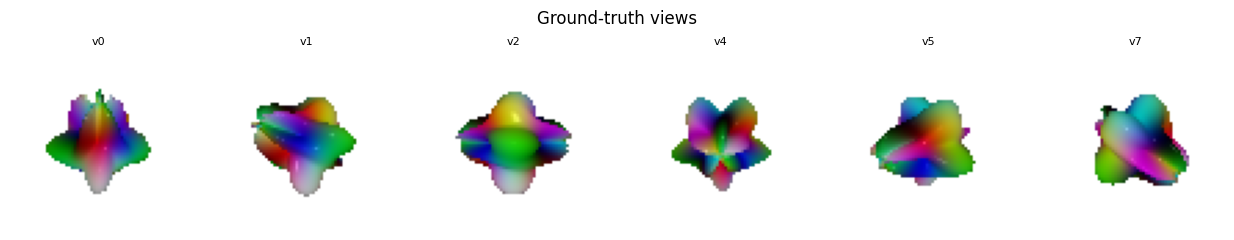

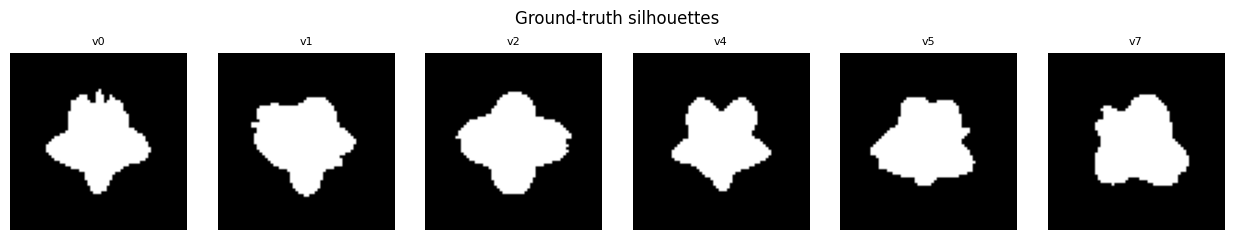

/usr/local/lib/python3.12/dist-packages/pytorch3d/ops/laplacian_matrices.py:51: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  A = torch.sparse.FloatTensor(idx, ones, (V, V))


[A1-coarse]    0/120  loss=0.20591
[A1-coarse]   20/120  loss=0.07596
[A1-coarse]   40/120  loss=0.03329
[A1-coarse]   60/120  loss=0.02039
[A1-coarse]   80/120  loss=0.01896
[A1-coarse]  100/120  loss=0.01426
[A1-coarse]  119/120  loss=0.01523
[A1-coarse] done in 268.2s
subdivided to 2562 verts
[A2-fine]    0/120  loss=0.00642
[A2-fine]   20/120  loss=0.00375


In [ ]:
with torch.no_grad():
    p_pred, n_pred = sample_points_from_meshes(final_mesh, 10000, return_normals=True)
    p_tgt,  n_tgt  = sample_points_from_meshes(target_mesh, 10000, return_normals=True)
    cd, cdn = chamfer_distance(p_pred, p_tgt, x_normals=n_pred, y_normals=n_tgt)

    init_sphere = ico_sphere(4, device)
    cd0, _ = chamfer_distance(sample_points_from_meshes(init_sphere, 10000), p_tgt)

    rec_rgb = renderer_hard(final_mesh.extend(N), cameras=cams_all,
                            lights=make_lights(cams_all))[..., :3]
    photo_mse = ((rec_rgb - tgt_rgb) ** 2).mean().item()

print("\n================ RESULTS ================")
print(f"Chamfer  sphere -> target : {cd0.item():.6f}   (starting point)")
print(f"Chamfer  recon  -> target : {cd.item():.6f}   "
      f"({100*(1-cd.item()/cd0.item()):.1f}% reduction)")
print(f"Normal consistency loss   : {cdn.item():.6f}   (lower = better aligned)")
print(f"Held-out photometric MSE  : {photo_mse:.6f}")
print(f"Mesh: {final_mesh.num_verts_per_mesh().item()} verts / "
      f"{final_mesh.num_faces_per_mesh().item()} faces")
print("=========================================\n")

show_grid(rec_rgb.cpu().numpy(), "Reconstruction (same viewpoints)")
show_grid(np.abs(rec_rgb.cpu().numpy() - tgt_rgb.cpu().numpy()), "|error| maps")

plt.figure(figsize=(11, 3))
for i, (h, t) in enumerate([(histA1 + histA2, "A: silhouette (coarse->fine)"),
                            (histB, "B: joint shape + appearance"),
                            (histC, "C: SE(3) pose recovery")]):
    plt.subplot(1, 3, i + 1); plt.plot(h, lw=0.8); plt.yscale("log")
    plt.title(t, fontsize=9); plt.xlabel("iter")
plt.tight_layout(); plt.show()

frames = []
with torch.no_grad():
    az = torch.linspace(-180, 180, 36)
    for i in range(0, 36, 6):
        a = az[i:i + 6]
        Rt, Tt = look_at_view_transform(dist=CFG["cam_dist"], elev=15.0, azim=a)
        c = FoVPerspectiveCameras(device=device, R=Rt.to(device), T=Tt.to(device))
        img = renderer_hard(final_mesh.extend(len(a)), cameras=c,
                            lights=make_lights(c))[..., :3]
        frames += [(f * 255).astype(np.uint8) for f in img.cpu().numpy().clip(0, 1)]

try:
    import imageio.v2 as imageio
    try:
        imageio.mimsave("turntable.gif", frames, duration=0.07, loop=0)
    except TypeError:
        imageio.mimsave("turntable.gif", frames, duration=0.07)
    from IPython.display import Image, display
    display(Image(filename="turntable.gif"))
    print("saved turntable.gif")
except Exception as e:
    print("GIF export skipped:", e)

v, f = final_mesh.get_mesh_verts_faces(0)
save_obj("reconstruction.obj", v, f)
print("saved reconstruction.obj  ->  open the Colab file browser to download")